In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from model import *
from utils import *
import pickle as pkl
import os
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set(style='whitegrid')
device = torch.device("cuda")

In [19]:
def plot_stuff(steps, lrs, train_losses, widths, ylim=None, note='NTK'):
    fig, axes = plt.subplots(1, len(steps), figsize=(5*len(steps), 4))
    for i in range(len(steps)):
        ax = axes[i]
        for idx, width in enumerate(widths):
            t_losses = [np.mean(train_losses[width][lr][steps[i]-800 : steps[i]+200]) for lr in lrs]
            ax.plot(lrs, t_losses, marker='s', markersize=3, alpha=0.6, linestyle='--', label=f'Width {width}')
        ax.set_title(f'{steps[i]} Steps '+note)
        ax.set_xlabel('Learning Rate')
        ax.set_xscale('log', base=2)
        if ylim is not None:
            ax.set_ylim(ylim[0], ylim[1])
        if i == 0:
            ax.legend()
            ax.set_ylabel('MSE Loss')

In [4]:
def sample_batch_teacher(B, d_in, device="cuda"):
        W1, W2, W3 = teacher_weights
        x = torch.randn(B, d_in, device=device) / math.sqrt(d_in)
        h = torch.tanh(x @ W1) * 1.5927
        h = torch.tanh(h @ W2) * 1.5927
        y = h @ W3
        return x, y

def train_ntp(d_in, widths, B, T, lrs, sample_batch_fn, device="cuda", type="NTP", verbose=False):
    train_losses = {w: {lr:[] for lr in lrs} for w in widths}
    loss_fn = nn.MSELoss()
    for width in widths:
        if verbose:
            print(f"Training width {width}")
        for lr in lrs:
            model = MLP2NTP(d_in, width, 1, type).to(device)
            model.init_weights()
            optimizer = model.init_optimizer(lr)
            model.train()
            for step in range(T):
                x, y_true = sample_batch_fn(B, d_in, device=device)
                optimizer.zero_grad()
                y_pred = model(x)
                loss = loss_fn(y_pred, y_true)
                loss.backward()
                optimizer.step()
                train_losses[width][lr].append(loss.item())
    return train_losses

Training width 256
Training width 512
Training width 1024
Training width 2048
Training width 4096


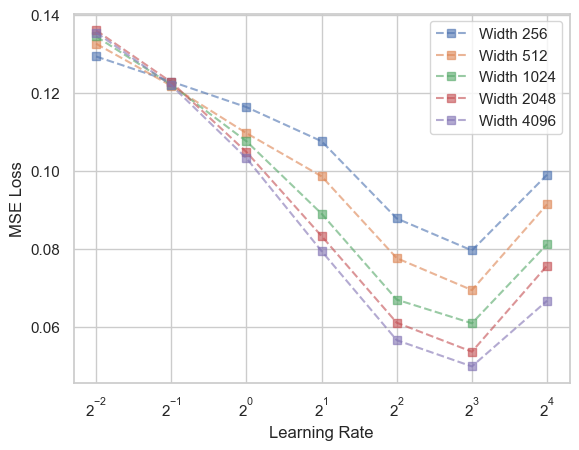

In [21]:
d_in=32
widths = [256, 512, 1024, 2048, 4096,]
B = 512
T = 8200
type = "NTP"
lrs = np.logspace(-2.0, 4.0, 7, base=2)
teacher_weights = make_teacher(d_in, device, seed=42, teacher_width = 16384)
train_losses_ntp = train_ntp(d_in, widths, B, T, lrs, sample_batch_teacher, device, type, verbose=True)
display_results(widths, lrs, train_losses_ntp)

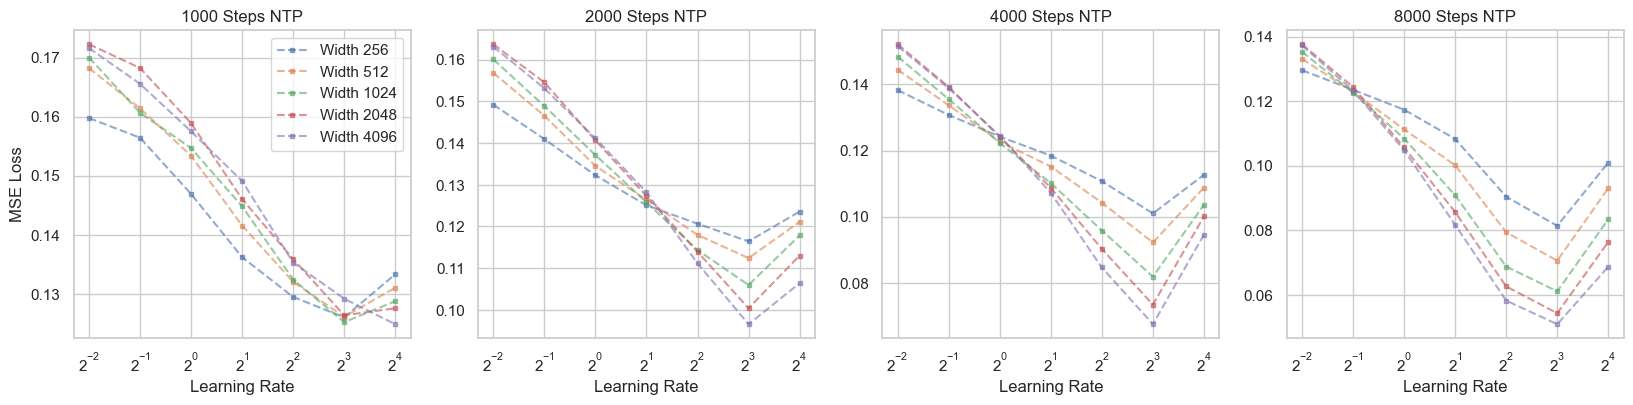

In [22]:
steps = [1000, 2000, 4000, 8000]
lrs = np.logspace(-2.0, 4.0, 7, base=2)
plot_stuff(steps, lrs, train_losses_ntp, widths, note="NTP")

Training width 256
Training width 512
Training width 1024
Training width 2048
Training width 4096


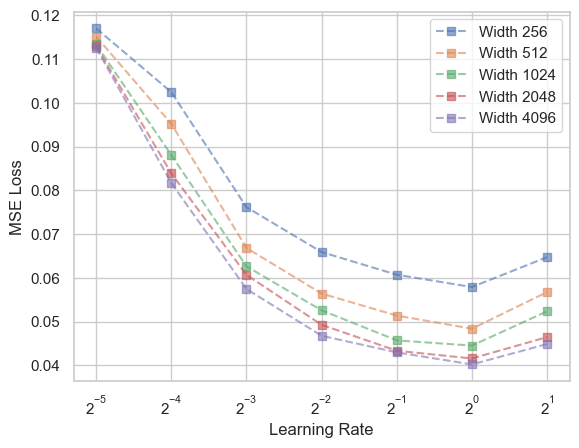

In [5]:
d_in=32
widths = [256, 512, 1024, 2048, 4096,]
B = 512
T = 8200
type = "MUP"
lrs = np.logspace(-5, 1.0, 7, base=2)
teacher_weights = make_teacher(d_in, device, seed=42, teacher_width = 16384)
train_losses_mup = train_ntp(d_in, widths, B, T, lrs, sample_batch_teacher, device, type, verbose=True)
display_results(widths, lrs, train_losses_mup)

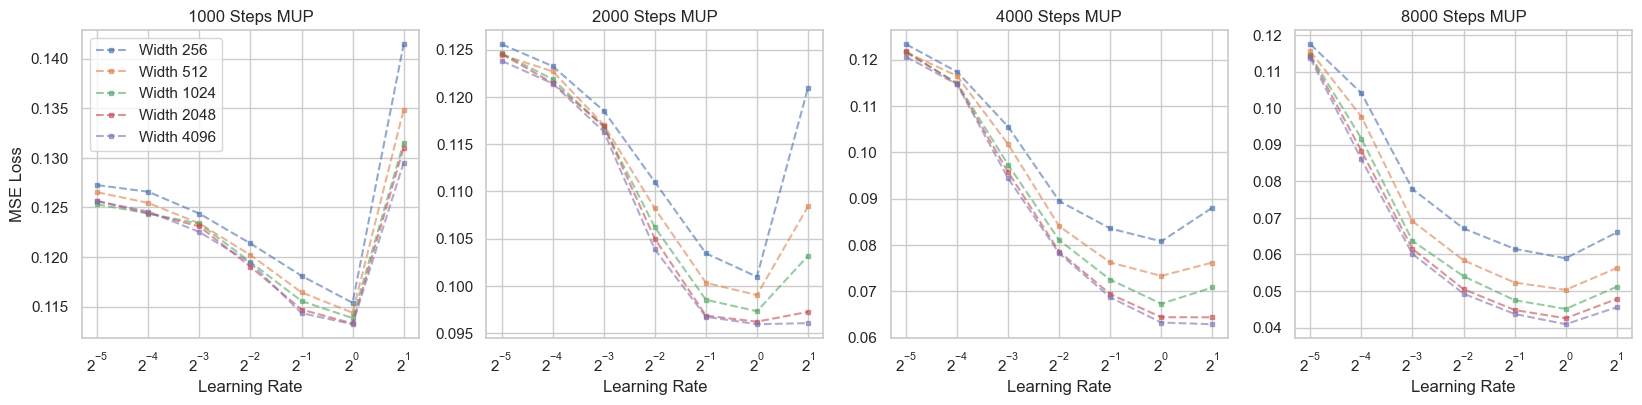

In [20]:
steps = [1000, 2000, 4000, 8000]
lrs = np.logspace(-5, 1.0, 7, base=2)
plot_stuff(steps, lrs, train_losses_mup, widths, note="MUP")

In [23]:
pkl.dump(train_losses_mup, open("assets_script2/train_losses_mup.pkl", "wb"))
pkl.dump(train_losses_ntp, open("assets_script2/train_losses_ntp.pkl", "wb"))

In [14]:
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

1.092943872 GB allocated
2.17055232 GB reserved
